# Construir y explorar la base de conocimiento

In [1]:
import json
import sys
sys.path.insert(0, "../src")

from scraper import build_knowledge_base

docs = build_knowledge_base()
print(f"Total documentos: {len(docs)}")
for doc in docs:
    print(f"- {doc['source']}: {len(doc['content'])} caracteres")

OK: acerca_de — 1728 caracteres
OK: enfoque_estrategico — 1506 caracteres
OK: sostenibilidad — 1669 caracteres
OK: historia — 20057 caracteres
OK: proposito — 2494 caracteres

Base de conocimiento guardada: 6 documentos
Total documentos: 6
- acerca_de: 1728 caracteres
- enfoque_estrategico: 1506 caracteres
- sostenibilidad: 1669 caracteres
- historia: 20057 caracteres
- proposito: 2494 caracteres
- resumen_corporativo: 1320 caracteres


# Analisis del corpus

                Fuente  Caracteres  Palabras  Lineas
0            acerca_de        1728       267      11
1  enfoque_estrategico        1506       236       8
2       sostenibilidad        1669       262      14
3             historia       20057      3038     164
4            proposito        2494       374      18
5  resumen_corporativo        1320       178      26


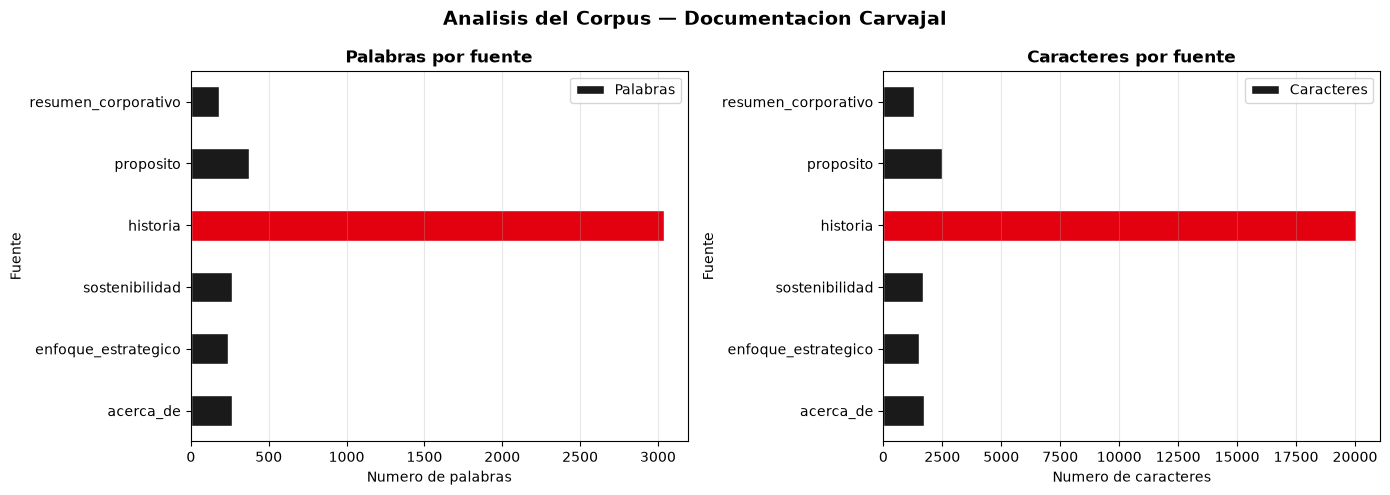

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.family"] = "DejaVu Sans"

with open("../data/knowledge_base.json", "r", encoding="utf-8") as f:
    docs = json.load(f)

df = pd.DataFrame([{
    "Fuente": d["source"],
    "Caracteres": len(d["content"]),
    "Palabras": len(d["content"].split()),
    "Lineas": len(d["content"].splitlines())
} for d in docs])

print(df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ["#E3000F" if i == df["Palabras"].idxmax() else "#1A1A1A"
          for i in range(len(df))]

df.plot(kind="barh", x="Fuente", y="Palabras", ax=axes[0],
        color=colors, edgecolor="white")
axes[0].set_title("Palabras por fuente", fontweight="bold")
axes[0].set_xlabel("Numero de palabras")
axes[0].grid(axis="x", alpha=0.3)

df.plot(kind="barh", x="Fuente", y="Caracteres", ax=axes[1],
        color=colors, edgecolor="white")
axes[1].set_title("Caracteres por fuente", fontweight="bold")
axes[1].set_xlabel("Numero de caracteres")
axes[1].grid(axis="x", alpha=0.3)

plt.suptitle("Analisis del Corpus — Documentacion Carvajal",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/eda_01_corpus.png", dpi=150, bbox_inches="tight")
plt.show()

# Construccion del vectorstore

In [3]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from vectorstore_builder import build_vectorstore

vectorstore = build_vectorstore()
print("Vectorstore construido exitosamente")

Cargando base de conocimiento...
Dividiendo documentos en chunks...
Total chunks: 74
Generando embeddings (puede tardar unos minutos)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Vectorstore guardado: 74 chunks indexados
Vectorstore construido exitosamente


# Analisis de chunks

Total chunks: 74

Chunks por fuente:
fuente
acerca_de               5
enfoque_estrategico     4
historia               51
proposito               6
resumen_corporativo     4
sostenibilidad          4
Name: chunk, dtype: int64


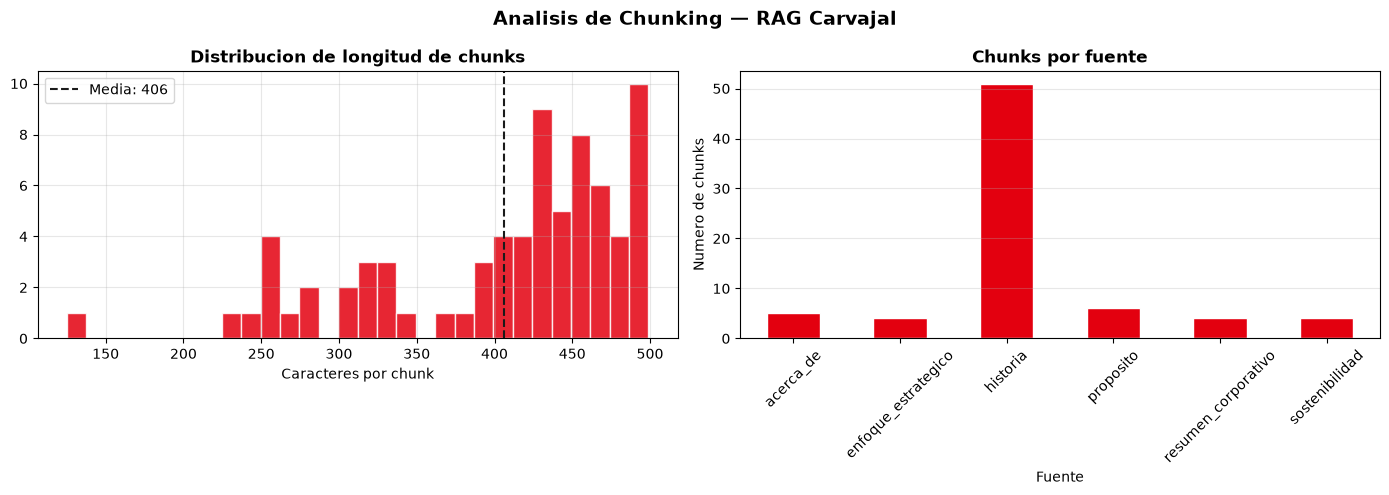

In [4]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=80)

all_chunks = []
for doc in docs:
    chunks = splitter.split_text(doc["content"])
    for chunk in chunks:
        all_chunks.append({
            "fuente": doc["source"],
            "chunk": chunk,
            "longitud": len(chunk)
        })

df_chunks = pd.DataFrame(all_chunks)
print(f"Total chunks: {len(df_chunks)}")
print(f"\nChunks por fuente:\n{df_chunks.groupby('fuente')['chunk'].count()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_chunks["longitud"].hist(bins=30, ax=axes[0], color="#E3000F",
                            edgecolor="white", alpha=0.85)
axes[0].axvline(df_chunks["longitud"].mean(), color="#1A1A1A",
                linestyle="--", label=f"Media: {df_chunks['longitud'].mean():.0f}")
axes[0].set_title("Distribucion de longitud de chunks", fontweight="bold")
axes[0].set_xlabel("Caracteres por chunk")
axes[0].legend()
axes[0].grid(alpha=0.3)

df_chunks.groupby("fuente")["chunk"].count().plot(
    kind="bar", ax=axes[1], color="#E3000F", edgecolor="white"
)
axes[1].set_title("Chunks por fuente", fontweight="bold")
axes[1].set_xlabel("Fuente")
axes[1].set_ylabel("Numero de chunks")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Analisis de Chunking — RAG Carvajal",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/eda_02_chunks.png", dpi=150, bbox_inches="tight")
plt.show()

# Test de recuperacion

In [ ]:
import os
GROQ_TOKEN = "GROQ_TOKEN"  # Reemplaza con tu token

os.environ["HUGGINGFACEHUB_API_TOKEN"] = GROQ_TOKEN

from rag_engine import build_rag_chain, query

print("Cargando cadena RAG...")
chain = build_rag_chain(GROQ_TOKEN)

preguntas_test = [
    "Cuales son los sectores de negocio de Carvajal?",
    "En cuantos paises opera Carvajal?",
    "Cuando fue fundada la empresa?",
]

print("\n--- PRUEBAS DE RECUPERACION ---")
for pregunta in preguntas_test:
    print(f"\nPregunta: {pregunta}")
    answer, sources = query(chain, pregunta)
    print(f"Respuesta: {answer[:300]}...")
    print(f"Fuentes: {sources}")

Cargando cadena RAG...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Vectorstore cargado

--- PRUEBAS DE RECUPERACION ---

Pregunta: Cuales son los sectores de negocio de Carvajal?
Respuesta: Los sectores de negocio de Carvajal son:

1. Empaques
2. Pulpa
3. Papel
4. Artículos escolares
5. Muebles de oficina
6. Tecnología
7. Sector inmobiliario...
Fuentes: ['acerca_de', 'resumen_corporativo', 'historia']

Pregunta: En cuantos paises opera Carvajal?
Respuesta: Carvajal opera en 12 países....
Fuentes: ['acerca_de', 'resumen_corporativo', 'historia']

Pregunta: Cuando fue fundada la empresa?
Respuesta: La empresa fue fundada en 1904 en Cali por Manuel Carvajal Valencia como una imprenta....
Fuentes: ['acerca_de', 'resumen_corporativo', 'historia']
